<a href="https://colab.research.google.com/github/marinaesca12/Simulaci-n-PAS-Paseo-Aleatorio-Simple-/blob/main/PAS_PRADO_(MarinaEsca%C3%B1uelaHueso).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
from matplotlib import pyplot as plt

## El núcleo: implementar una función para simular el PAS

Definimos una función `simular_PAS` que reciba tres argumentos:
* p: Este es el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería $1-p$). Es un valor entre 0 y 1.
* n: El número de pasos a simular para cada trayectoria. Un número natural.
* reps: El número de trayectorias a simular. Un número natural.

La función debe devolver un array de numpy con dimensionalidad `(reps, n)`, que contenga los valores del PAS en cada paso para cada trayectoria.  

In [27]:
def simular_PAS(p,n,reps=1):
  # Input:

  # p: Probabilidad de que el paso sea positivo. Toma valores entre 0 y 1.
  # n: Número de pasos
  # reps: Número de trayectorias independientes del PAS a generar.

  # Generamos una matriz de tamaño (reps,n) de valores aleatorios:
  matriz = np.random.rand(reps,n) #Shape: (reps,n)

  # Creamos una matriz en la que si el valor de la matriz anterior es menor que p entonces nos devuelve un 1 y, si no un -1:
  resultado = np.where(matriz < p, 1, -1) #Shape: (reps,n)

  # Generamos una matriz cuyos elementos son la acumulación por filas de sus valores:
  # Ejemplo : matriz = np.array([[1,2,3],[5,6,7]])
  # np.cunsum(matriz,axis=1) nos devuelve [[ 1  3  6],[ 4  9 15]]
  matrizacum = np.cumsum(resultado, axis=1) #Shape: (reps,n)

  # Output:
  # output: Obtenemos una matriz donde cada fila es una trayectoria y cada columna un tiempo t

  return matrizacum  # Shape: (reps, n)

----------------------------------------

## Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

Escribimos el código para crear las imágenes de las diapositivas 16 ($p=0.5$), 17 ($p=0.6$) y 18 ($p=0.4$) del tema 1.

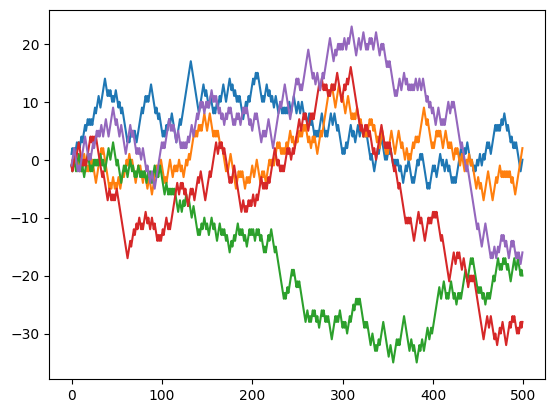

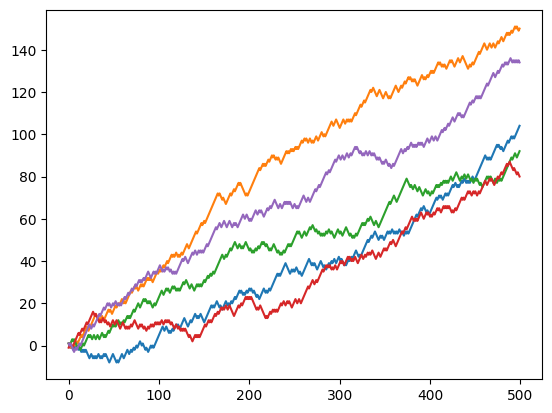

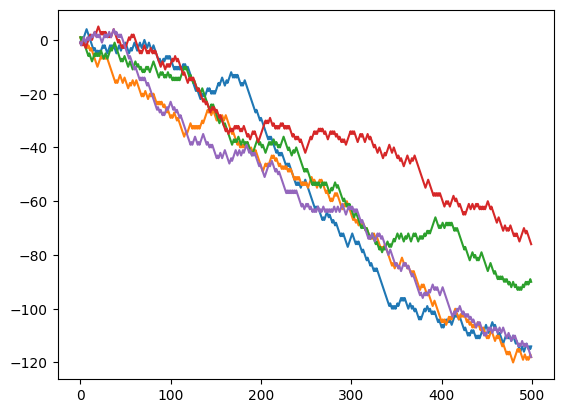

In [28]:
# Generamos el PAS en las condiciones pedidas :
simular_PAS(0.5,500,reps=5)

# Creamos la gráfica y trasponemos nuestra matriz que es de tamaño 5x500 para que sea de tamaño 500x5 y que así nos aparezcan las 5 trayectorias (y no 500).
plt.plot(simular_PAS(0.5,500,reps=5).T)

# Para que nos aparezca la gráfica usamos :
plt.show()

# Análogamente para p=0.6 :
simular_PAS(0.6,500,reps=5)
plt.plot(simular_PAS(0.6,500,reps=5).T)
plt.show()

# Y p=0.4 :
simular_PAS(0.4,500,reps=5)
plt.plot(simular_PAS(0.4,500,reps=5).T)
plt.show()


## Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

Escribimos el código para crear las imágenes de las diapositivas 30 ($p=0.5$), 31 ($p=0.75$), 32 ($p=0.95$) del tema 1.

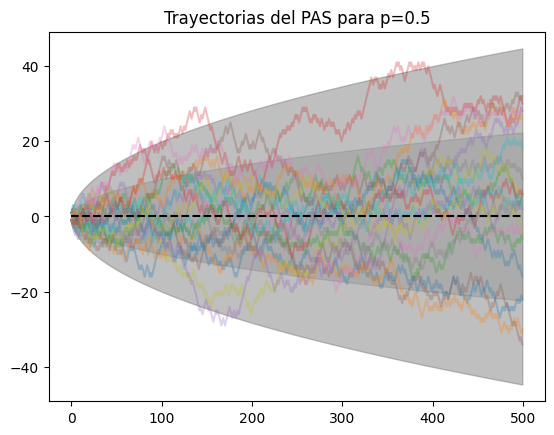

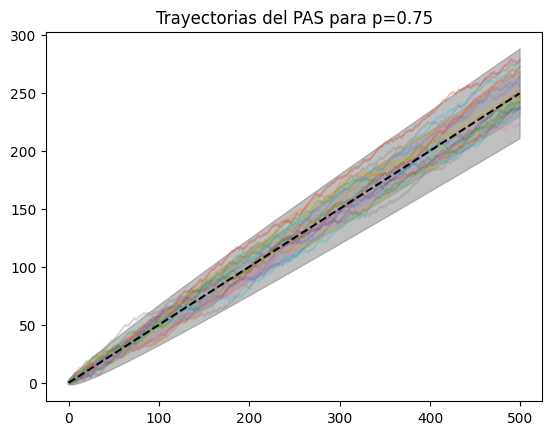

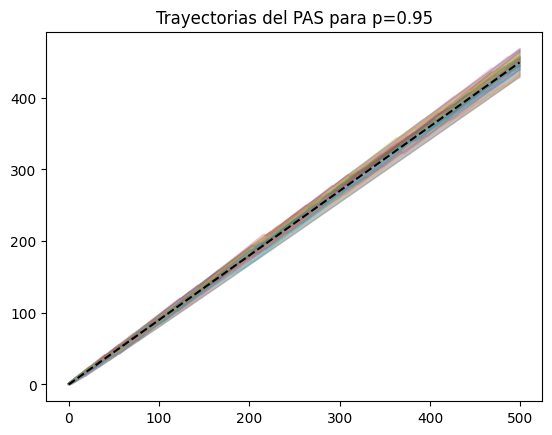

In [29]:
# Generamos la simulación :
n=500
p=0.5
trayectorias = simular_PAS(p,n,reps=20) # Redefinimos nuestra función para que nos sea más fácil usarla a lo largo del ejercicio
plt.plot(trayectorias.T,alpha =0.3)

# Definimos un vector de tiempo :
t = np.arange(n) # Obtenemos un vector fila con elementos desde el 0 hasta n-1

# Calculamos el vector de medias :
vecmedias = (2*p -1)*t

# Ahora calculamos el vector de las desviaciones típicas :
varianza = 4*p*t*(1-p)
desvtipica = np.sqrt(varianza)

# Dibujamos la media teórica :
plt.plot(vecmedias, color ='black', linestyle = '--')

# Generamos un sombreado en el intervalo ±1 sigma y ±2 sigma:
plt.fill_between(t, vecmedias - desvtipica, vecmedias + desvtipica, color='gray', alpha=0.3)
plt.fill_between(t, vecmedias - 2*desvtipica, vecmedias + 2*desvtipica, color='gray', alpha=0.5)

# Creamos un título :
plt.title('Trayectorias del PAS para p=0.5')
plt.show()

# Análogamente para 0.75:
n=500
p=0.75
trayectorias = simular_PAS(p,n,reps=20)
plt.plot(trayectorias.T,alpha =0.3)

vecmedias = (2*p -1)*t
varianza = 4*p*t*(1-p)
desvtipica = np.sqrt(varianza)

plt.plot(vecmedias, color ='black', linestyle = '--')
plt.fill_between(t, vecmedias - desvtipica, vecmedias + desvtipica, color='gray', alpha=0.3)
plt.fill_between(t, vecmedias - 2*desvtipica, vecmedias + 2*desvtipica, color='gray', alpha=0.5)
plt.title('Trayectorias del PAS para p=0.75')
plt.show()

# Y para 0.95 :
n=500
p=0.95
trayectorias = simular_PAS(p,n,reps=20)
plt.plot(trayectorias.T,alpha =0.3)

vecmedias = (2*p -1)*t
varianza = 4*p*t*(1-p)
desvtipica = np.sqrt(varianza)

plt.plot(vecmedias, color ='black', linestyle = '--')
plt.fill_between(t, vecmedias - desvtipica, vecmedias + desvtipica, color='gray', alpha=0.3)
plt.fill_between(t, vecmedias - 2*desvtipica, vecmedias + 2*desvtipica, color='gray', alpha=0.5)
plt.title('Trayectorias del PAS para p=0.95')
plt.show()

## Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

Escribir código para crear la imagen de la diapositiva 35.

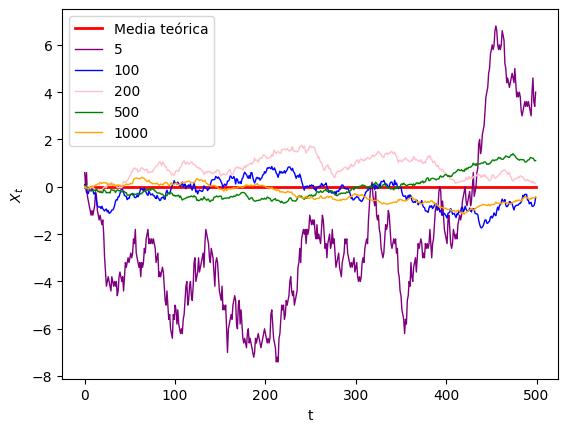

In [30]:
# Definimos los parámetros iniciales :
n = 500
p = 0.5

# Definimos un vector de tiempo :
t = np.arange(n)

# Calculamos y dibujamos la media teórica :
vecmedias = (2*p -1)*t
plt.plot(t, vecmedias, color='red', label='Media teórica', linewidth=2)

# Casos 5, 100, 200, 500 y 1000 trayectorias :

# Caso 5 trayectorias :
trayectorias_5 = simular_PAS(p, n, reps=5)
media_5 = np.mean(trayectorias_5, axis=0) # Calculamos la media por columnas (axis=0) y nos devuelve un vector fila con todas las medias
plt.plot(t, media_5, color='purple', label='5', linewidth=1)

# Caso 100 trayectorias :
trayectorias_100 = simular_PAS(p, n, reps=100)
media_100 = np.mean(trayectorias_100, axis=0)
plt.plot(t, media_100, color='blue', label='100', linewidth=1)

# Caso 200 trayectorias :
trayectorias_200 = simular_PAS(p, n, reps=200)
media_200 = np.mean(trayectorias_200, axis=0)
plt.plot(t, media_200, color='pink', label='200', linewidth=1)

# Caso 500 trayectorias :
trayectorias_500 = simular_PAS(p, n, reps=500)
media_500 = np.mean(trayectorias_500, axis=0)
plt.plot(t, media_500, color='green', label='500', linewidth=1)

# Caso 1000 trayectorias :
trayectorias_1000 = simular_PAS(p, n, reps=1000)
media_1000 = np.mean(trayectorias_1000, axis=0)
plt.plot(t, media_1000, color='orange', label='1000', linewidth=1)

# Ajustes finales de la gráfica
plt.xlabel('t')
plt.ylabel('$X_t$')
plt.legend() # Para que aparezca la leyenda
plt.show()